In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data_path = "melb_data_cleaned.csv"
df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      10480 non-null  str    
 1   Rooms       10480 non-null  int64  
 2   Type        10480 non-null  str    
 3   Price       10480 non-null  float64
 4   Date        10480 non-null  str    
 5   Distance    10480 non-null  float64
 6   Bedroom2    10480 non-null  int64  
 7   Bathroom    10480 non-null  int64  
 8   Car         10480 non-null  int64  
 9   Landsize    10480 non-null  float64
 10  Lattitude   10480 non-null  float64
 11  Longtitude  10480 non-null  float64
 12  Regionname  10480 non-null  str    
 13  year        10480 non-null  int64  
 14  month       10480 non-null  int64  
 15  Type_h      10480 non-null  bool   
 16  Type_t      10480 non-null  bool   
 17  Type_u      10480 non-null  bool   
 18  Region_EM   10480 non-null  bool   
 19  Region_NM   10480 non-null  bool   


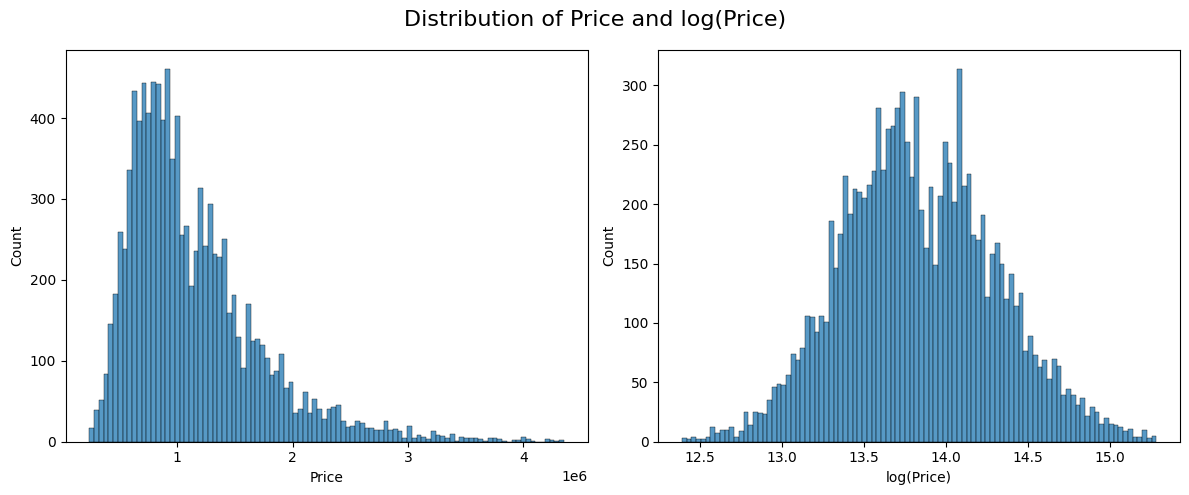

In [9]:
# 1. Nhìn lại phân phối của Price và log(Price)
plt.figure(figsize=(12,5))

# Price distribution
plt.subplot(1,2,1)
sns.histplot(df["Price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")

# log(Price) distribution
plt.subplot(1,2,2)
sns.histplot(df["log_price"], bins=100)
plt.xlabel("log(Price)")
plt.ylabel("Count")
plt.suptitle("Distribution of Price and log(Price)", fontsize=16)
plt.tight_layout()
plt.show()

### Nhận xét:
Price bị lệch phải, trong khi log_price gần như tuân theo phân phối chuẩn.

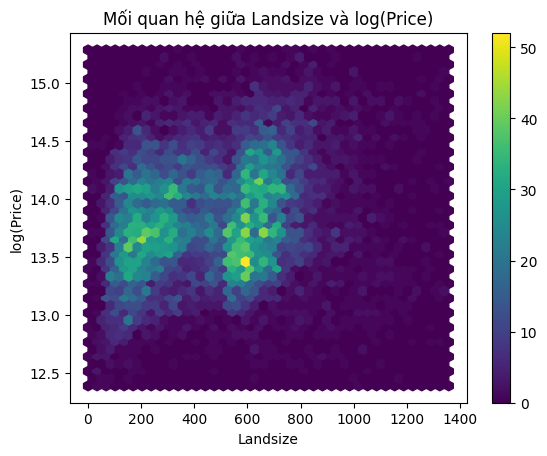

In [10]:
# 2. Phân tích mối quan hệ giữa Landsize và log(Price)
plt.figure()
plt.hexbin(df["Landsize"], df["log_price"], gridsize=40)
plt.xlabel("Landsize")
plt.ylabel("log(Price)")
plt.title("Mối quan hệ giữa Landsize và log(Price)")
plt.colorbar()
plt.show()

### Nhận xét
Khi Landsize tăng, Price có xu hướng tăng nhẹ.<br>
Độ phân tán cao.<br>
Có 2 vùng nổi bật trong biểu đồ tại Landsize = 200, và Landsize = 600. Cho thấy thị trường có nhiều bất động sản với diện tích là 200 m^2 và 600 m^2.</p>

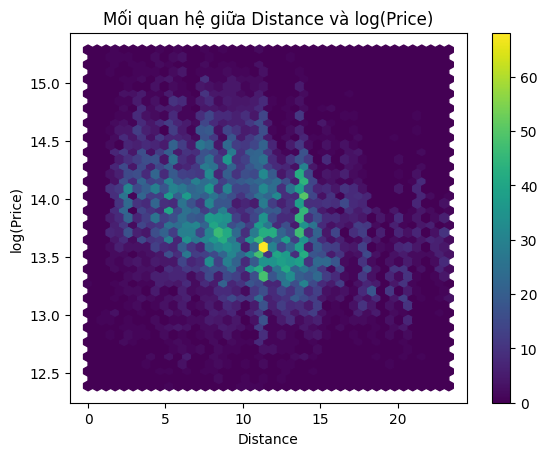

In [11]:
# 3. Phân tích mối quan hệ giữa Distance và log(Price)
plt.figure()
plt.hexbin(df["Distance"], df["log_price"], gridsize=40)
plt.xlabel("Distance")
plt.ylabel("log(Price)")
plt.title("Mối quan hệ giữa Distance và log(Price)")
plt.colorbar()
plt.show()

### Nhận xét:
Dữ liệu tập trung cao ở khoảng 5-15 km.<br>
Tương quan âm nhẹ, độ lệch cao (dễ hiểu do càng gần CBD thì càng thuận tiện, nhu cầu cao, giá cũng tăng cao).</p>

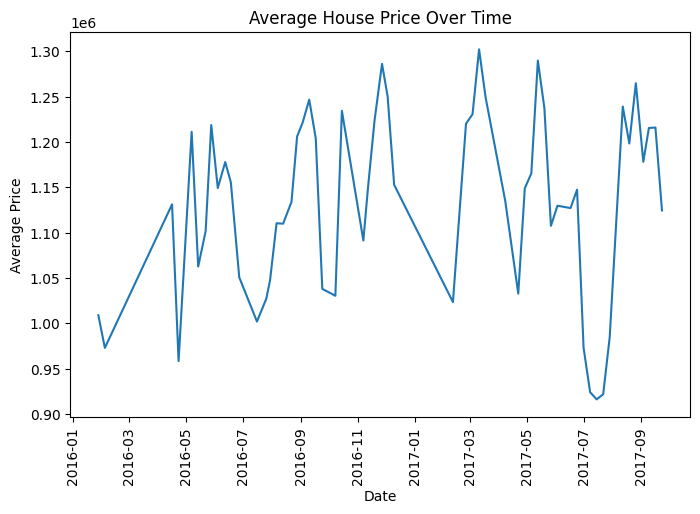

In [12]:
# 4. Biến động giá nhà theo thời gian (2015-2017)
df["Date"] = pd.to_datetime(df["Date"])
price_by_date = df.groupby("Date")["Price"].mean()
plt.figure(figsize=(8,5))
plt.plot(price_by_date.index, price_by_date.values)
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Average Price")
plt.title("Average House Price Over Time")
plt.show()

### Nhận xét
Giá cả có xu hướng tăng nhẹ theo thời gian.<br>
Nhưng do hạn chế từ bộ dữ liệu, xu hướng này không được thể hiện rõ mà có nhiều biến động.<br>
Thậm chí, dữ liệu bị thiếu vào tháng 07-2017 gây khó khăn cho việc phân tích.<br>

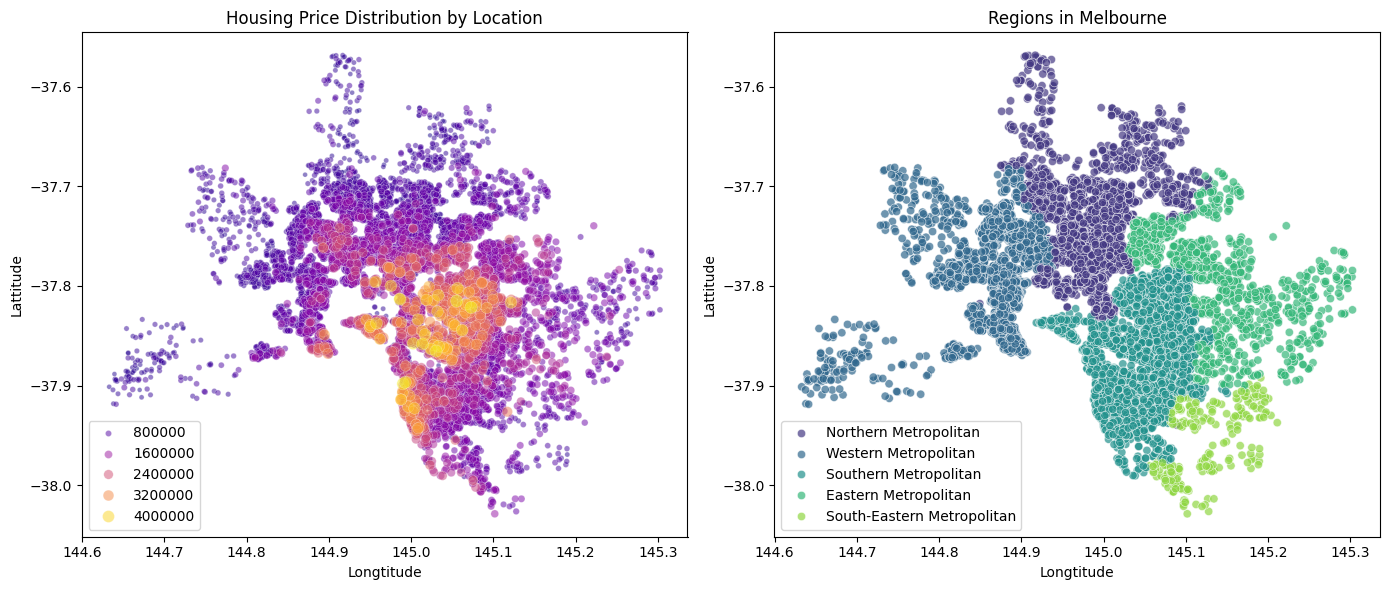

In [58]:
# 5. Phân bố giá cả theo kinh-vĩ độ
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)

sns.scatterplot(
    data=df.sort_values(by='Price'),
    x="Longtitude",
    y="Lattitude",
    hue="Price",
    palette="plasma",
    alpha=0.5,
    size="Price",
    sizes=(10,80)
)
plt.legend(loc="lower left")
plt.tight_layout()
plt.title("Housing Price Distribution by Location")


plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x="Longtitude",
    y="Lattitude",
    hue="Regionname",
    palette="viridis",
    alpha=0.7,
    sizes=(10,80)
)
plt.legend(loc="lower left")
plt.tight_layout()
plt.title("Regions in Melbourne")
plt.show()


### Nhận xét:
Giá thành cao tập trung chủ yếu ở Southern Metropolitan và lan sang các vùng lân cận.<br>
Dự đoán rằng feature region_SM sẽ ảnh hưởng lớn đến dự đoán giá nhất trong 4 vùng, tiếp sau đấy có thể là region_NM và region_WM.